# **"Implementation of the Isolation Forest Algorithm in Detecting Anomalous Parameters in Four-Wheeled Vehicle Data"**

##🧠 Goals:
####**Mendeteksi fitur (parameter sensor) yang menyimpang** pada data kendaraan yang memiliki kode kerusakan P0351, P0352, P0353, dan P0354 (Ignition Coil "A, B, C, dan D") menggunakan:
####**Algoritma Isolation Forest** → untuk deteksi anomali
####**SHAP (SHapley Additive exPlanations)** → untuk menjelaskan fitur mana yang berkontribusi pada anomali

### Vehicle Data: [Data Normal & Data Symptomatic](https://drive.google.com/drive/folders/1mM41Pv54S8DdGpfYMicOhzKU_avdYhTk?usp=sharing)

### Tidak menggunakan parameter numerik (konstan), parameter sinyal, parameter sinyal biner (changing), parameter spesifikasi

## *1. Import Data*

In [27]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# Import Data Kendaraan Normal dan Rusak
data_normal = pd.read_csv('/content/drive/MyDrive/Trouble Scenario Data (Label)/Real Data/Label/Normal Data (Toyota) Label.csv')
data_symptomatic = pd.read_csv('/content/drive/MyDrive/Trouble Scenario Data (Label)/Real Data/Label/Failure Data (Toyota) Label.csv')

In [30]:
# Ringkasan Tabel
display(Markdown("### Jumlah Data"))

summary = pd.DataFrame({
    "Dataset": ["Data Normal", "Data Symptomatic"],
    "Jumlah Baris": [data_normal.shape[0], data_symptomatic.shape[0]],
    "Jumlah Kolom": [data_normal.shape[1], data_symptomatic.shape[1]]
})

# Tambahkan total
total_baris = data_normal.shape[0] + data_symptomatic.shape[0]
total_kolom = data_normal.shape[1]
summary.loc[len(summary.index)] = ["Total", total_baris, total_kolom]

display(summary)


### Jumlah Data

,Dataset,Jumlah Baris,Jumlah Kolom
0,Data Normal,198,92
1,Data Symptomatic,198,92
2,Total,396,92


In [31]:
# Tampilkan 5 data pertama
display(Markdown("### Data Normal (5 Baris Pertama)"))
display(data_normal.head())

display(Markdown("### Data Kondisi Rusak (5 Baris Pertama)"))
display(data_symptomatic.head())

### Data Normal (5 Baris Pertama)

,SampleTime,VehicleSpeed,EngineSpeed,CalculateLoad,MAF,AtmospherePressure,CoolantTemp,IntakeAir,EngineRunTime,InitialEngineCoolantTemp,...,IdleFuelCut,FCTAU,ModelCode,EngineType,CylinderNumber,TransmissionType,Destination,ModelYear,SystemIdentification,Label
0,00:00.000,0,753,19.6,2.93,97,75,28,271,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
1,00:00.282,0,756,19.6,2.96,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
2,00:00.565,0,759,19.2,2.92,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
3,00:00.847,0,749,20.0,2.96,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
4,00:01.130,0,756,19.6,2.95,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal


### Data Kondisi Rusak (5 Baris Pertama)

,SampleTime,VehicleSpeed,EngineSpeed,CalculateLoad,MAF,AtmospherePressure,CoolantTemp,IntakeAir,EngineRunTime,InitialEngineCoolantTemp,...,IdleFuelCut,FCTAU,ModelCode,EngineType,CylinderNumber,TransmissionType,Destination,ModelYear,SystemIdentification,Label
0,00:00.000,0,705,18.0,2.53,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
1,00:00.324,0,706,18.0,2.51,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
2,00:00.606,0,710,17.6,2.51,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
3,00:00.889,0,707,17.6,2.50,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
4,00:01.171,0,703,18.0,2.53,101,85,30,890,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali


## *2. Preprocessing Data*


#### Data Intergration (Penggabunggan Data)

In [32]:
# Gabungkan kedua data (Data Normal + Data Symptomatic (Data Kendaraan Rusak))
data_all = pd.concat([data_normal, data_symptomatic], ignore_index=True)

In [33]:
print (data_all.dtypes)

SampleTime               object
VehicleSpeed              int64
EngineSpeed               int64
CalculateLoad           float64
MAF                     float64
                         ...   
TransmissionType          int64
Destination               int64
ModelYear                 int64
SystemIdentification      int64
Label                    object
Length: 92, dtype: object


#### Checking Missing Value

In [34]:
# Cek missing value
missing_count = data_all.isnull().sum().sum()

# We will modify the logic to ensure 'Normal' data is not dropped
if missing_count == 0:
    print("Tidak ada missing value dalam dataset.")
    df = data_all.copy()
else:
    print(f"Ditemukan {missing_count} missing value. Mengisi nilai yang kosong.")
    # Apply ffill and fillna with mean directly on data_all to retain all rows
    df = data_all.copy() # Start with a copy to avoid modifying data_all directly if not intended
    df = df.ffill()
    df = df.fillna(df.mean(numeric_only=True))

# --- Now, df should contain both Normal and Anomali data with missing values handled ---

Tidak ada missing value dalam dataset.


#### Checking Duplicate Data

In [35]:
def cek_duplikat(dataframe, nama_dataset):
    # Tentukan kolom yang diperiksa (kecuali SampleTime dan label)
    cols_to_check = [col for col in dataframe.columns if col not in ['SampleTime', 'label']]

    # Deteksi duplikat
    duplicate_rows = dataframe.duplicated(subset=cols_to_check, keep=False)
    duplicate_count = duplicate_rows.sum()

    # Tampilkan hasil
    if duplicate_count == 0:
        print(f"Tidak ada duplikat dalam {nama_dataset}.")
    else:
        print(f"Terdapat {duplicate_count} baris duplikat dalam {nama_dataset}. Menampilkan contoh:")
        display(dataframe[duplicate_rows].head())

        # (Opsional) Hapus duplikat jika ingin
        print(f"Menghapus duplikat dari {nama_dataset}...")
        dataframe = dataframe.drop_duplicates(subset=cols_to_check)
        print(f"Duplikat dalam {nama_dataset} berhasil dihapus.")

    return dataframe

# 🔍 Cek masing-masing dataset secara terpisah
data_normal = cek_duplikat(data_normal, "Data Normal")
data_symptomatic = cek_duplikat(data_symptomatic, "Data Symptomatic")

# 🔗 Gabungkan kembali setelah duplikat dihapus (jika diinginkan)
data_all = pd.concat([data_normal, data_symptomatic], ignore_index=True)
df = data_all.copy()


Tidak ada duplikat dalam Data Normal.
Tidak ada duplikat dalam Data Symptomatic.


#### Drop Feature (Feature Selection)

In [36]:
fitur_dibuang = [
    # --- Parameter Numerik ---
    # "CalculateLoad", "MAF", "CoolantTemp", "Injector(Port)", "BatteryVoltage",
    # "AccelSens.No.1Volt%", "AccelSens.No.2Volt%", "AccelSensorOutNo.1",
    # "AccelSensorOutNo.2", "AccelFullyClose#1(AD)", "AccelFullyCloseLearn#1",
    # "AccelFullyCloseLearn#2", "ThrottleSensorVolt%", "ThrottleSensor2Volt%",
    # "ThrottleRequirePosition", "ThrottleSensorPosition", "ThrottlePositionNo.1",
    # "ThrottlePositionNo.2", "ThrottlePositionCommand", "ThrottleSensOpen#1(AD)",
    # "ThrottleMotorCurrent", "ThrottleMotorDUTY", "ThrottleMotorDuty(Open)",
    # "ThrottleMotorDuty(Close)", "+BMVoltage", "InjectionVolum(Cylinder1)",
    # "EvapPurgeFlow", "O2SB1S1", "ShortFTB1S1", "LongFTB1S1", "O2FTB1S1", "IGNAdvance",
    # "TargetAir-FuelRatio",

    # --- Parameter Numerik (Tidak digunakan) ---
    "SampleTime", "EngineRunTime","EngineSpeed", "VehicleSpeed",
    "IntakeAir", "InitialEngineCoolantTemp", "InitialIntakeAirTemp", "AtmospherePressure", "ThrottleFullyCloseLearn", "ThrottleSensOpenPos#1",
    "KnockFeedbackValue", "KnockCorrectLearnValue",

    # --- Parameter Sinyal (Konstan) ---
    "FCTAU", "TCandTE1", "ElectricalLoadSignal", "A/CSignal", "StopLightSwitch",
    "PowerSteeringSignal", "StarterSignal", "VVTOCVDuty#1", "VVTChangeAngle#1", "VVTAimAngle#1", "EVAPPurgeVSV",
    "EVAPPurgeVSV", "OpenSideMalfunction", "ST1", "ACTVSV", "PowerSteer.Sig.Record", "FuelSystemStatus#1",
    "FuelPump/SpeedStatus", "ActuatorPowerSupply", "ETCSActuatorPower", "ThrottleMotor",
    "ThrottleSensOpenPos#2",
    "SystemGuard",

    # --- Parameter Sinyal (Changing) ---
    "AcceleratorIdlePosition", "ThrottleIdlePosition", "VVTControlStatus#1",
    "ClosedThrottlePositionSW", "IdleFuelCut",
    "PurgeDensityLearnValue",

    # --- Parameter Spesifikasi/Identitas ---
    "FailSafeDrive", "FailSafeDrive(MainCPU)", "CheckMode",
    "SPDTestResult", "#Codes(IncludeHistory)", "MIL", "TimeafterDTCCleared",
    "DistancefromDTCCleared", "WarmupCycleClearedDTC", "OBDRequirements", "NumberofEmissionDTC",
    "ModelCode", "EngineType", "CylinderNumber", "TransmissionType", "Destination", "ModelYear",
    "SystemIdentification"
]

# --- Filter hanya kolom yang memang ada di df ---
fitur_dibuang_valid = [f for f in fitur_dibuang if f in df.columns]

# --- Drop fitur ---
if fitur_dibuang_valid:
    print(f'Menghapus fitur: {fitur_dibuang_valid}')
    df_reduced = df.drop(columns=fitur_dibuang_valid)
else:
    print('ℹTidak ada fitur yang sesuai untuk dihapus.')
    df_reduced = df.copy()

# --- Output hasil ---
print(f'Dataset akhir memiliki {df_reduced.shape[1]} fitur dan {df_reduced.shape[0]} baris.')

# --- Tampilkan 5 data pertama ---
print('\nData setelah fitur dibuang:')
display(df_reduced.head())


Menghapus fitur: ['SampleTime', 'EngineRunTime', 'EngineSpeed', 'VehicleSpeed', 'IntakeAir', 'InitialEngineCoolantTemp', 'InitialIntakeAirTemp', 'AtmospherePressure', 'ThrottleFullyCloseLearn', 'ThrottleSensOpenPos#1', 'KnockFeedbackValue', 'KnockCorrectLearnValue', 'FCTAU', 'TCandTE1', 'ElectricalLoadSignal', 'A/CSignal', 'StopLightSwitch', 'PowerSteeringSignal', 'StarterSignal', 'VVTOCVDuty#1', 'VVTChangeAngle#1', 'VVTAimAngle#1', 'EVAPPurgeVSV', 'EVAPPurgeVSV', 'OpenSideMalfunction', 'ST1', 'ACTVSV', 'PowerSteer.Sig.Record', 'FuelSystemStatus#1', 'FuelPump/SpeedStatus', 'ActuatorPowerSupply', 'ETCSActuatorPower', 'ThrottleMotor', 'ThrottleSensOpenPos#2', 'SystemGuard', 'AcceleratorIdlePosition', 'ThrottleIdlePosition', 'VVTControlStatus#1', 'ClosedThrottlePositionSW', 'IdleFuelCut', 'PurgeDensityLearnValue', 'FailSafeDrive', 'FailSafeDrive(MainCPU)', 'CheckMode', 'SPDTestResult', '#Codes(IncludeHistory)', 'MIL', 'TimeafterDTCCleared', 'DistancefromDTCCleared', 'WarmupCycleClearedDTC

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,Injector(Port),InjectionVolum(Cylinder1),EvapPurgeFlow,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,Label
0,19.6,2.93,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.44,-1.6,2.3,-1.563,8.5,Normal
1,19.6,2.96,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,0.0,2.3,0.000,7.5,Normal
2,19.2,2.92,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,0.7,2.3,0.781,7.0,Normal
3,20.0,2.96,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,1.5,2.3,1.562,7.5,Normal
4,19.6,2.95,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,2.3,2.3,2.343,6.5,Normal


#### Data Transformation (StandarScaler)

In [37]:
X = df_reduced.drop(columns=['Label'])
y = df_reduced['Label'].apply(lambda x: 1 if x == 'Anomali' else 0)  # 1=Anomali, 0=Normal

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

In [38]:
#  Pilih parameter yang ingin ditampilkan
param = 'CalculateLoad'

sample_idx = X.sample(5, random_state=42).index

df_compare = pd.DataFrame({
    'Before_Standardization': X.loc[sample_idx, param].values,
    'After_Standardization': X_scaled.loc[sample_idx, param].values
}).reset_index(drop=True)

print(f"Perbandingan nilai '{param}' sebelum dan sesudah standarisasi (5 baris acak):")
display(df_compare)

Perbandingan nilai 'CalculateLoad' sebelum dan sesudah standarisasi (5 baris acak):


,Before_Standardization,After_Standardization
0,9.0,-1.283999
1,18.0,-0.266529
2,17.6,-0.311750
3,20.0,-0.040425
4,23.9,0.400479


## *3. Exploratory Data Analysis*


#### Statistik Deskriptif

In [39]:
display(Markdown("## Statistik Deskriptif"))
display(df_reduced.describe())

## Statistik Deskriptif

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,+BMVoltage,Injector(Port),InjectionVolum(Cylinder1),EvapPurgeFlow,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance
count,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,...,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000
mean,20.357576,5.564141,81.424242,13.645707,18.081313,34.019697,0.848990,1.622475,0.848990,19.830808,...,13.613889,2.466843,0.122621,0.518687,0.999934,0.431818,0.584848,1.637879,0.623073,14.457071
std,8.856660,5.238837,3.832812,0.135970,4.512273,4.487481,0.222924,0.227979,0.222924,0.370303,...,0.187681,0.857915,0.048245,0.725244,0.000248,0.339845,2.533487,1.254190,2.536514,10.008385
min,5.400000,2.480000,75.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,13.400000,1.150000,0.060000,0.000000,0.999000,0.000000,-7.100000,0.000000,-7.032000,-2.500000
25%,18.000000,2.530000,78.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,13.400000,2.300000,0.103000,0.000000,1.000000,0.070000,-0.800000,0.700000,-0.782000,7.500000
50%,18.800000,3.280000,82.500000,13.650000,16.000000,31.700000,0.800000,1.500000,0.800000,19.750000,...,13.550000,2.300000,0.108000,0.000000,1.000000,0.640000,0.000000,1.500000,0.000000,9.000000
75%,20.700000,7.502500,85.000000,13.800000,21.100000,36.900000,1.000000,1.800000,1.000000,20.000000,...,13.800000,2.560000,0.121000,1.600000,1.000000,0.760000,1.500000,2.300000,1.562000,22.125000
max,88.600000,64.120000,85.000000,13.900000,50.500000,66.600000,2.500000,3.300000,2.500000,20.500000,...,13.900000,9.600000,0.460000,1.600000,1.000000,0.850000,9.300000,16.400000,9.375000,35.000000


#### Plot Histogram

#### Plot Histogram

In [40]:
import math

/tmp/ipython-input-502785787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


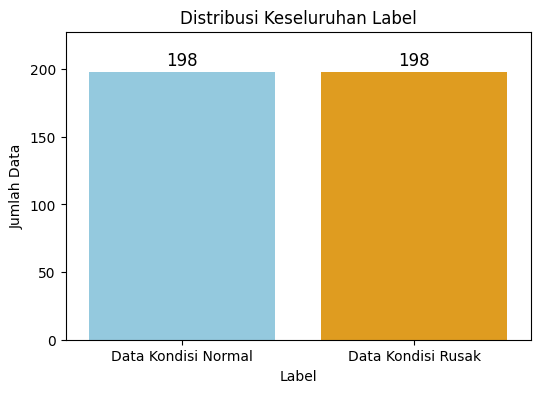

In [41]:
plt.figure(figsize=(6,4))
label_counts = y.map({0: 'Data Kondisi Normal', 1: 'Data Kondisi Rusak'}).value_counts()

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette={'Data Kondisi Normal': 'skyblue', 'Data Kondisi Rusak': 'orange'}
)

plt.title("Distribusi Keseluruhan Label")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

for i, val in enumerate(label_counts.values):
    plt.text(i, val + 5, str(val), ha='center', fontsize=12)

plt.ylim(0, max(label_counts.values) * 1.15)

plt.show()

## *4. Isolation Forest Implementation*

#### Isolation Forest Implementation - Pengujian Augmentasi Data Menggunakan Teknik Jittering

In [42]:
# Pisahkan data normal & anomali berdasarkan label
X_normal = X_scaled[y == 0]
X_anomali = X_scaled[y == 1]


In [43]:
print("Jumlah data awal:")
print(f"- Normal  : {len(X_normal)}")
print(f"- Anomali : {len(X_anomali)}")

X_train_normal, X_test_normal = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print("\nJumlah data normal:")
print(f"- Train normal (asli) : {len(X_train_normal)}")
print(f"- Test normal (asli)  : {len(X_test_normal)}")

# Augmentasi Data (Jittering)
np.random.seed(42)
noise_factor = 0.005

# Target: test normal = jumlah test anomali
jumlah_normal_test = len(X_test_normal)
jumlah_anomali_test = len(X_anomali)

tambahan = jumlah_anomali_test - jumlah_normal_test

print("\nAugmentasi test normal:")
print(f"- Normal test awal   : {jumlah_normal_test}")
print(f"- Anomali test       : {jumlah_anomali_test}")
print(f"- Tambahan dibutuhkan: {tambahan}")

if tambahan > 0:
    # sampling ulang data test normal
    X_sample = X_test_normal.sample(
        n=tambahan,
        replace=True,
        random_state=42
    )

    # jittering
    noise = np.random.normal(
        loc=0,
        scale=noise_factor * X_sample.std(),
        size=X_sample.shape
    )

    X_test_normal_aug = X_sample + noise

    # normal test = asli + augmented
    X_test_normal_final = pd.concat(
        [X_test_normal, X_test_normal_aug],
        ignore_index=True
    )
else:
    X_test_normal_final = X_test_normal.copy()

print(f"- Normal test final  : {len(X_test_normal_final)}")

X_test = pd.concat(
    [X_test_normal_final, X_anomali],
    ignore_index=True
)

y_test = pd.Series(
    [0]*len(X_test_normal_final) + [1]*len(X_anomali)
)

print("\nJumlah data test final:")
print(f"- Test normal  : {len(X_test_normal_final)}")
print(f"- Test anomali : {len(X_anomali)}")
print(f"- Total test   : {len(X_test)}")

# Isolation Forest Model
model = IsolationForest(
    n_estimators=100,
    contamination= "auto",
    random_state=42
)

model.fit(X_train_normal)

y_pred = model.predict(X_test)   # -1 = Anomali, 1 = Normal
y_pred = np.where(y_pred == -1, 1, 0)

anomaly_score = model.decision_function(X_test)


Jumlah data awal:
- Normal  : 198
- Anomali : 198

Jumlah data normal:
- Train normal (asli) : 158
- Test normal (asli)  : 40

Augmentasi test normal:
- Normal test awal   : 40
- Anomali test       : 198
- Tambahan dibutuhkan: 158
- Normal test final  : 198

Jumlah data test final:
- Test normal  : 198
- Test anomali : 198
- Total test   : 396


In [49]:
# Gabungkan test normal asli + augmented
X_check = pd.concat(
    [X_test_normal, X_test_normal_aug],
    ignore_index=True
)

# Cek duplikasi baris persis
duplikasi_persis = X_check.duplicated().sum()

print("Cek duplikasi persis:")
print(f"- Jumlah baris duplikat: {duplikasi_persis}")


Cek duplikasi persis:
- Jumlah baris duplikat: 0


Confusion Matrix (detail):
True Negative (TN) = 112  → Normal diprediksi Normal
False Positive (FP) = 86 → Normal diprediksi Anomali
False Negative (FN) = 1 → Anomali diprediksi Normal
True Positive (TP) = 197  → Anomali diprediksi Anomali

Evaluation Metrics:
Accuracy  : 0.7803
Precision : 0.6961
Recall    : 0.9949
F1-score  : 0.8191

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.57      0.72       198
     Anomali       0.70      0.99      0.82       198

    accuracy                           0.78       396
   macro avg       0.84      0.78      0.77       396
weighted avg       0.84      0.78      0.77       396



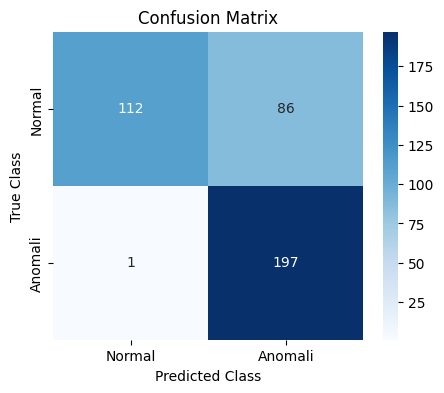

False Positive Rate (FPR): 0.4343
FPR (%): 43.43%


In [44]:
# Evaluasi Model
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix (detail):")
print(f"True Negative (TN) = {tn}  → Normal diprediksi Normal")
print(f"False Positive (FP) = {fp} → Normal diprediksi Anomali")
print(f"False Negative (FN) = {fn} → Anomali diprediksi Normal")
print(f"True Positive (TP) = {tp}  → Anomali diprediksi Anomali\n")

# Hitung metrik evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Anomali']))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

fpr = fp / (fp + tn)

print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"FPR (%): {fpr*100:.2f}%")

In [45]:
df_hasil = X_test.copy()
df_hasil['True_Label'] = y_test
df_hasil['Prediksi'] = y_pred
df_hasil['Anomaly_Score'] = anomaly_score

df_hasil['Prediksi_Label'] = df_hasil['Prediksi'].map({0: 'Normal', 1: 'Anomali'})

anomali_terdeteksi = df_hasil[df_hasil['Prediksi'] == 1]
normal_terdeteksi = df_hasil[df_hasil['Prediksi'] == 0]

print("Ringkasan Hasil Deteksi:")
print("-------------------------------------")
print(f"Jumlah Data Anomali Terdeteksi : {len(anomali_terdeteksi)}")
print(f"Jumlah Data Normal Terdeteksi  : {len(normal_terdeteksi)}")
print("-------------------------------------")
print(f"Total Data                     : {len(df_hasil)}")

print("\nSeluruh Data Anomali Terdeteksi:")
display(anomali_terdeteksi)

Ringkasan Hasil Deteksi:
-------------------------------------
Jumlah Data Anomali Terdeteksi : 283
Jumlah Data Normal Terdeteksi  : 113
-------------------------------------
Total Data                     : 396

Seluruh Data Anomali Terdeteksi:


,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,True_Label,Prediksi,Anomaly_Score,Prediksi_Label
1,-0.006509,0.626094,-0.894532,1.136192,0.847359,0.888101,0.678263,0.779675,0.678263,1.809432,...,0.265085,0.849054,-1.179649,0.528595,-1.171224,1.304849,0,1,-0.000095,Anomali
3,-0.040425,1.325606,-0.372062,1.872579,1.202396,1.245100,1.127413,1.218866,1.127413,1.809432,...,0.265085,0.731204,0.677849,1.167264,0.678925,2.055168,0,1,-0.021111,Anomali
5,-0.085646,0.914690,-0.633297,1.136192,1.024878,0.977351,1.127413,1.218866,1.127413,1.809432,...,0.265085,0.849054,-1.495819,1.167264,-1.479517,1.755041,0,1,-0.021229,Anomali
6,-0.006509,1.348541,-0.372062,1.872579,1.202396,1.245100,1.127413,1.218866,1.127413,1.809432,...,0.265085,-1.124929,0.045509,1.167264,0.062340,2.005147,0,1,-0.018042,Anomali
7,-0.311750,-0.006525,-1.678238,1.136192,0.492322,0.441853,0.678263,0.340484,0.678263,0.457479,...,0.265085,-1.066004,2.851516,-0.110074,2.837761,0.904678,0,1,-0.094126,Anomali
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,0.400479,-0.251163,0.672878,-0.336581,-0.550599,-0.517580,-0.669189,-0.537898,-0.669189,-0.894474,...,0.265085,-1.242779,1.586837,-0.748743,1.604197,-0.395876,1,1,-0.070452,Anomali
392,0.490921,-0.293211,0.672878,-1.072967,-0.550599,-0.517580,-0.669189,-0.537898,-0.669189,-0.894474,...,0.265085,-1.242779,1.903007,-0.748743,1.912489,-0.395876,1,1,-0.075314,Anomali
393,0.705720,-0.279832,0.672878,-1.072967,-0.550599,-0.517580,-0.669189,-0.537898,-0.669189,-0.894474,...,0.265085,-1.242779,2.219177,-0.748743,2.221177,-0.395876,1,1,-0.111618,Anomali
394,0.886603,-0.287477,0.672878,-1.072967,-0.550599,-0.517580,-0.669189,-0.537898,-0.669189,-0.894474,...,0.265085,-1.242779,2.535347,-0.748743,2.529469,-0.395876,1,1,-0.120387,Anomali


In [46]:
display(normal_terdeteksi)

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,True_Label,Prediksi,Anomaly_Score,Prediksi_Label
0,0.038712,1.400144,-1.417002,1.136192,1.202396,1.245100,1.127413,1.218866,1.127413,0.457479,...,0.265085,0.849054,0.994019,1.167264,0.987612,2.005147,0,0,0.022781,Normal
2,-0.085646,-0.503446,-1.678238,0.399806,-0.461839,-0.517580,-0.220038,-0.537898,-0.220038,0.457479,...,0.265085,-1.007079,0.361679,0.528595,0.370633,-0.746025,0,0,0.110104,Normal
4,-0.176087,-0.449932,-0.372062,1.136192,-0.461839,-0.517580,-0.220038,-0.537898,-0.220038,0.457479,...,0.265085,-1.183854,0.994019,0.528595,0.987612,-0.746025,0,0,0.074986,Normal
8,-0.085646,-0.503446,-1.678238,0.399806,-0.461839,-0.517580,-0.220038,-0.537898,-0.220038,0.457479,...,0.265085,-1.007079,0.677849,0.528595,0.678925,-0.796046,0,0,0.101868,Normal
9,-0.221308,-0.493890,-0.110827,0.399806,-0.461839,-0.517580,-0.220038,-0.537898,-0.220038,0.457479,...,0.265085,0.849054,-0.863479,0.528595,-0.862932,-0.295833,0,0,0.071613,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,0.038565,1.402324,-1.412495,1.135702,1.202652,1.245827,1.134956,1.210533,1.129567,0.457115,...,0.270752,0.852687,0.994064,1.166765,0.988003,2.002068,0,0,0.021994,Normal
192,-0.008603,0.899638,-0.632869,1.137076,1.024664,0.974576,1.126827,1.212517,1.134593,1.805518,...,0.262204,1.088854,0.050997,1.162909,0.062228,1.661748,0,0,0.004053,Normal
194,-0.085562,-0.507573,-1.675602,0.404965,-0.461902,-0.515674,-0.219772,-0.540730,-0.225779,0.455241,...,0.265373,-1.009460,0.374691,0.528512,0.363465,-0.746832,0,0,0.107069,Normal
195,-0.085129,-0.493165,-1.679862,0.396294,-0.458827,-0.522792,-0.221414,-0.538921,-0.220258,0.459664,...,0.268751,-0.950173,0.998671,0.528855,0.986978,-0.797318,0,0,0.092522,Normal


##### SHAP Value (Find Trouble Parameter)

In [47]:
import shap

/tmp/ipython-input-1717971526.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


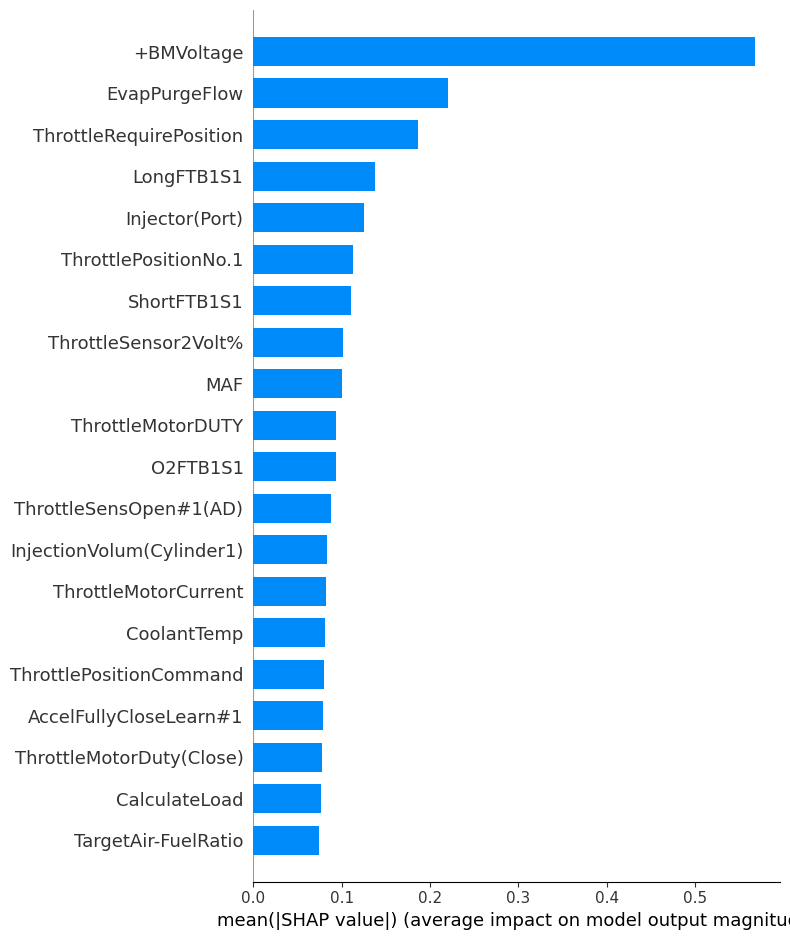

In [48]:
X_test_shap = X_test.copy()
X_test_shap = X_test_shap.reset_index(drop=True)

df_hasil_shap = df_hasil.copy()
df_hasil_shap = df_hasil_shap.reset_index(drop=True)

explainer = shap.TreeExplainer(model)

shap_values_test = explainer.shap_values(X_test_shap)

# Ambil hanya data test yang diprediksi sebagai Anomali
anomali_idx = df_hasil_shap[df_hasil_shap['Prediksi_Label'] == 'Anomali'].index

X_anomali_for_shap = X_test_shap.loc[anomali_idx]
shap_values_anomali_for_shap = shap_values_test[anomali_idx]

# Visualisasi SHAP (bar plot)
shap.summary_plot(
    shap_values_anomali_for_shap,
    X_anomali_for_shap,
    plot_type="bar",
    show=True
)
